# LoRA Fine-Tuning Assignment

## Objective

Fine-tune **TinyLlama-1.1B** on the **databricks-dolly-15k** dataset using LoRA.


---
## Part 0 — Setup

In [1]:
# Install dependencies
!pip install -U transformers trl peft datasets accelerate -q

# Show installed versions (torch and torchvision should both be listed)
!pip list 2>/dev/null | grep -i -E "^(torch|torchvision|transformers|trl|peft) "

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 109.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 925.0/925.0 kB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.9/832.9 kB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 32.4 MB/s eta 0:00:00
peft                                  0.21.0
torch                                 2.11.0+cu128
torchvision                           0.26.0+cu128
transformers                          5.17.0
trl                                   1.14.0


In [3]:
import torch
import gc
import os
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, PeftModel, get_peft_model
from trl import SFTConfig, SFTTrainer

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


### Utility functions

In [4]:
def clear_memory():
    """Free GPU memory between experiments."""
    gc.collect()
    torch.cuda.empty_cache()
    if torch.cuda.is_available():
        print(f"GPU allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
        print(f"GPU reserved:  {torch.cuda.memory_reserved() / 1024**3:.2f} GB")


def print_trainable_params(model):
    """Display trainable vs total parameter counts."""
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"Trainable parameters: {trainable:>12,}  ({100 * trainable / total:.4f}%)")
    print(f"Total parameters:     {total:>12,}")


def generate_response(model, tokenizer, prompt, max_new_tokens=256):
    """Generate a response from a model given a prompt string."""
    messages = [{"role": "user", "content": prompt}]
    input_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(input_text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.7,
            top_p=0.9,
            do_sample=True,
            pad_token_id=tokenizer.pad_token_id,
        )
    response = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    return response

---
## Part 1 — Configuration

### Task 1: Define all hyperparameters

Set the following configuration variables:

| Variable | Value |
|---|---|
| `MODEL_NAME` | `"TinyLlama/TinyLlama-1.1B-Chat-v1.0"` |
| `DATASET_NAME` | `"databricks/databricks-dolly-15k"` |
| `NUM_TRAIN_SAMPLES` | `1000` |
| `MAX_SEQ_LENGTH` | `512` |
| `LORA_R` | `8` |
| `LORA_ALPHA` | `16` |
| `LORA_DROPOUT` | `0.05` |
| `LORA_TARGET_MODULES` | `["q_proj", "v_proj"]` (attention only) |
| `LEARNING_RATE` | `2e-4` |
| `NUM_EPOCHS` | `1` |
| `BATCH_SIZE` | `4` |
| `GRAD_ACCUM_STEPS` | `4` |
| `OUTPUT_DIR` | `"./sft-lora-tinyllama"` |

In [5]:
# ---------------------------------------------------------------
# Task 1.1 — Hyperparameters defined ONCE as named constants.
# Every later phase (model loading, dataset prep, LoRA config,
# training, saving) reads from these, so tuning = editing one cell.
# ---------------------------------------------------------------

# Model / data
MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
DATASET_NAME = "databricks/databricks-dolly-15k"
NUM_TRAIN_SAMPLES = 1000
MAX_SEQ_LENGTH = 512
SEED = 42

# LoRA
LORA_R = 8
LORA_ALPHA = 16
LORA_DROPOUT = 0.05
LORA_TARGET_MODULES = ["q_proj", "v_proj"]   # attention only

# Training
LEARNING_RATE = 2e-4
NUM_EPOCHS = 1
BATCH_SIZE = 4
GRAD_ACCUM_STEPS = 4

# Output
OUTPUT_DIR = "./sft-lora-tinyllama"

print(f"Model:               {MODEL_NAME}")
print(f"Dataset:             {DATASET_NAME}  ({NUM_TRAIN_SAMPLES} samples)")
print(f"Max seq length:      {MAX_SEQ_LENGTH}")
print(f"LoRA:                r={LORA_R}, alpha={LORA_ALPHA}, dropout={LORA_DROPOUT}, targets={LORA_TARGET_MODULES}")
print(f"Effective batch size: {BATCH_SIZE} x {GRAD_ACCUM_STEPS} = {BATCH_SIZE * GRAD_ACCUM_STEPS}")

Model:               TinyLlama/TinyLlama-1.1B-Chat-v1.0
Dataset:             databricks/databricks-dolly-15k  (1000 samples)
Max seq length:      512
LoRA:                r=8, alpha=16, dropout=0.05, targets=['q_proj', 'v_proj']
Effective batch size: 4 x 4 = 16


---
## Part 2 — Load Model and Tokenizer

### Task 2: Load the tokenizer and base model

1. Load the tokenizer from `MODEL_NAME`.
2. If the tokenizer has no pad token, set it to the eos token.
3. Load the model in `float16` with `device_map="auto"`.
4. Print the total parameter count.

In [6]:
# Task 1.2 — Load tokenizer + base model (T4-friendly settings)

# 1. Tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# 2. Make sure a pad token exists (needed for batching)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# 3. Model in float16 (~2.2 GB instead of ~4.4 GB in fp32) and placed on the GPU automatically
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.float16,
    device_map="auto",
)

# 4. Total parameter count
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")
print(f"Model dtype:      {next(model.parameters()).dtype}")
print(f"Model device:     {model.device}")

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

tokenizer.model: reconstructing file:   0%|          |  0.00B /  500kB            

tokenizer.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.20GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Total parameters: 1,100,048,384
Model dtype:      torch.float16
Model device:     cuda:0


---
## Part 3 — Test Base Model

### Task 3: Generate responses from the base model

Use the provided `generate_response` function with these test prompts:
1. `"Explain what a neural network is in 2-3 sentences."`
2. `"What are three tips for better sleep?"`

Store the responses in a list called `base_responses` for later comparison.

In [7]:
# Task 1.3 — Fixed test prompts + baseline responses
# The SAME list (test_prompts) is reused in Task 8, so the base-vs-fine-tuned
# comparison is apples-to-apples.

test_prompts = [
    "Explain what a neural network is in 2-3 sentences.",
    "What are three tips for better sleep?",
]

base_responses = []
for prompt in test_prompts:
    response = generate_response(model, tokenizer, prompt)
    base_responses.append(response)          # store each response as it is produced

    print("=" * 80)
    print(f"PROMPT: {prompt}")
    print("-" * 80)
    print(f"BASE MODEL: {response}")

[transformers] Both `max_new_tokens` (=256) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


PROMPT: Explain what a neural network is in 2-3 sentences.
--------------------------------------------------------------------------------
BASE MODEL: A neural network is a mathematical model that uses a hierarchy of interconnected computing units (neurons) to simulate the process of perception, learning, and decision-making in the brain. Neural networks are trained using data to learn specific tasks, such as recognizing faces, detecting patterns, and making predictions. They are often used in machine learning and artificial intelligence applications.
PROMPT: What are three tips for better sleep?
--------------------------------------------------------------------------------
BASE MODEL: Sure, here are three tips for better sleep:

1. Create a relaxing sleep environment: Make your bedroom a calming and comfortable place to sleep. Avoid distractions, such as televisions or smartphones. Keep the room cool and quiet.

2. Avoid caffeine and alcohol before bedtime: Caffeine and alcohol can

---
## Part 4 — Prepare the Dataset

### Task 4: Load and format the Dolly dataset

The Dolly dataset has columns: `instruction`, `context`, `response`, `category`.

1. Load the dataset (`split="train"`).
2. Write a function `format_dolly_to_chat(example)` that converts each example to:
   ```python
   {"messages": [
       {"role": "user", "content": <instruction + context if present>},
       {"role": "assistant", "content": <response>}
   ]}
   ```
   If `context` is non-empty, concatenate it to the instruction with a newline separator.
3. Shuffle with `seed=42`, select `NUM_TRAIN_SAMPLES` examples, and apply the formatting function.
4. Print the size of the formatted dataset and one example.



```
Example formatted entry:
{'messages': [{'content': 'Who were the children of the legendary Garth Greenhand, the High King of the First Men in the series A Song of Ice and Fire?', 'role': 'user'}, {'content': 'Garth the Gardener, John the Oak, Gilbert of the Vines, Brandon of the Bloody Blade, Foss the Archer, Owen Oakenshield, Harlon the Hunter, Herndon of the Horn, Bors the Breaker, Florys the Fox, Maris the Maid, Rose of the Red Lake, Ellyn Ever Sweet, Rowan Gold-Tree', 'role': 'assistant'}]}
```



In [8]:
# Task 2.1 — Load Dolly-15K and inspect shape + columns
raw_dataset = load_dataset(DATASET_NAME, split="train")

print(f"Shape:   {raw_dataset.shape}")
print(f"Columns: {raw_dataset.column_names}")
print("\nRaw example (note: flat fields, NOT a messages list):")
print(raw_dataset[0])


# Task 2.2 — Convert each example to a chat-style messages list
def format_dolly_to_chat(example):
    instruction = (example.get("instruction") or "").strip()
    context = (example.get("context") or "").strip()
    response = (example.get("response") or "").strip()

    # Merge context into the USER turn only when it is actually present,
    # otherwise we'd end up with a dangling "\n" at the end of the prompt.
    user_content = f"{instruction}\n{context}" if context else instruction

    return {
        "messages": [
            {"role": "user", "content": user_content},
            {"role": "assistant", "content": response},
        ]
    }


# Task 2.3 — Shuffle FIRST (Dolly is ordered by category/contributor, so taking the
# first N rows would give a biased, unrepresentative subset), then select and format.
train_dataset = (
    raw_dataset
    .shuffle(seed=SEED)
    .select(range(NUM_TRAIN_SAMPLES))
    .map(format_dolly_to_chat, remove_columns=raw_dataset.column_names)
)

print(f"\nFormatted dataset size: {len(train_dataset)}")
print(f"Columns after formatting: {train_dataset.column_names}")
print("\nExample formatted entry:")
print(train_dataset[0])

README.md:   0%|          | 0.00/8.20k [00:00<?, ?B/s]

databricks-dolly-15k.jsonl: reconstructing file:   0%|          |  0.00B / 13.1MB            

databricks-dolly-15k.jsonl: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/15011 [00:00<?, ? examples/s]

Shape:   (15011, 4)
Columns: ['instruction', 'context', 'response', 'category']

Raw example (note: flat fields, NOT a messages list):
{'instruction': 'When did Virgin Australia start operating?', 'context': "Virgin Australia, the trading name of Virgin Australia Airlines Pty Ltd, is an Australian-based airline. It is the largest airline by fleet size to use the Virgin brand. It commenced services on 31 August 2000 as Virgin Blue, with two aircraft on a single route. It suddenly found itself as a major airline in Australia's domestic market after the collapse of Ansett Australia in September 2001. The airline has since grown to directly serve 32 cities in Australia, from hubs in Brisbane, Melbourne and Sydney.", 'response': 'Virgin Australia commenced services on 31 August 2000 as Virgin Blue, with two aircraft on a single route.', 'category': 'closed_qa'}


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]


Formatted dataset size: 1000
Columns after formatting: ['messages']

Example formatted entry:
{'messages': [{'content': 'Who were the children of the legendary Garth Greenhand, the High King of the First Men in the series A Song of Ice and Fire?', 'role': 'user'}, {'content': 'Garth the Gardener, John the Oak, Gilbert of the Vines, Brandon of the Bloody Blade, Foss the Archer, Owen Oakenshield, Harlon the Hunter, Herndon of the Horn, Bors the Breaker, Florys the Fox, Maris the Maid, Rose of the Red Lake, Ellyn Ever Sweet, Rowan Gold-Tree', 'role': 'assistant'}]}


---
## Part 5 — Configure LoRA

### Task 5: Create the LoRA config and inspect trainable parameters

1. Create a `LoraConfig` using the hyperparameters from Task 1. Set `bias="none"` and `task_type="CAUSAL_LM"`.
2. Apply it to the model with `get_peft_model`.
3. Use `print_trainable_params` to display the trainable vs total parameters.
4. Print the LoRA-wrapped structure of one attention layer (e.g., `q_proj` of layer 0).

In [9]:
# Task 3.1 — LoRA config targeting attention projections only (q_proj, v_proj)
lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=LORA_TARGET_MODULES,
    bias="none",
    task_type="CAUSAL_LM",
)

# Task 3.2 — get_peft_model freezes the base weights and injects trainable adapters
model = get_peft_model(model, lora_config)

# Task 3.3 — Verify LoRA trains only a tiny fraction of the parameters
print_trainable_params(model)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
pct = 100 * trainable / total
assert pct < 1.0, f"Expected <1% trainable parameters, got {pct:.4f}%"
print(f"\nCheck passed: only {pct:.4f}% of parameters are trainable (< 1%).")

# Inspect the LoRA-wrapped q_proj of layer 0
print("\nLoRA-wrapped q_proj of layer 0:")
print(model.base_model.model.model.layers[0].self_attn.q_proj)

Trainable parameters:    1,126,400  (0.1023%)
Total parameters:     1,101,174,784

Check passed: only 0.1023% of parameters are trainable (< 1%).

LoRA-wrapped q_proj of layer 0:
lora.Linear(
  (base_layer): Linear(in_features=2048, out_features=2048, bias=False)
  (lora_dropout): ModuleDict(
    (default): Dropout(p=0.05, inplace=False)
  )
  (lora_A): ModuleDict(
    (default): Linear(in_features=2048, out_features=8, bias=False)
  )
  (lora_B): ModuleDict(
    (default): Linear(in_features=8, out_features=2048, bias=False)
  )
  (lora_embedding_A): ParameterDict()
  (lora_embedding_B): ParameterDict()
  (lora_magnitude_vector): ModuleDict()
)


---
## Part 6 — Train

### Task 6: Set up SFTTrainer and run training

1. Delete the PEFT-wrapped model and call `clear_memory()`. Reload the base model fresh (SFTTrainer applies LoRA itself via `peft_config`).
2. Create an `SFTConfig` with the hyperparameters from Task 1. Include:
   - Cosine LR scheduler, warmup ratio 0.03, weight decay 0.01
   - `gradient_checkpointing=True`
   - bf16 if supported, else fp16
   - `max_length=MAX_SEQ_LENGTH`
   - Logging every 10 steps
3. Create an `SFTTrainer` with the model, training args, dataset, tokenizer, and `peft_config`.
4. Call `trainer.train()` and print the final loss.

GPU allocated: 0.01 GB
GPU reserved:  2.05 GB


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Tokenizing train dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (4117 > 2048). Running this sequence through the model will result in indexing errors


Building labels for train dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Dropping fully masked examples from train dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Model inside the trainer (should be LoRA-wrapped):
PeftModelForCausalLM
Trainable parameters:    1,126,400  (0.1023%)
Total parameters:     1,101,174,784


Step,Training Loss
10,2.110638
20,1.879643
30,1.760444
40,1.735813
50,1.780847
60,1.723896



Logged training loss (step, loss):
  step   10: 2.1106
  step   20: 1.8796
  step   30: 1.7604
  step   40: 1.7358
  step   50: 1.7808
  step   60: 1.7239

Final logged loss:      1.7239
Average training loss:  1.8312


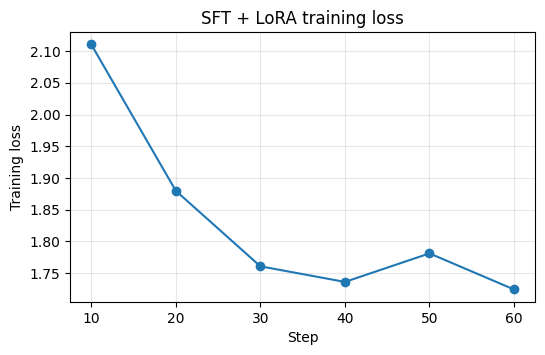

In [10]:
# ---- Clean up the PEFT-wrapped model from Task 5 and reload a fresh base model ----
del model
clear_memory()

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.float16,
    device_map="auto",
)

# ---- Task 4.1 — SFTConfig (sized for a T4) ----
# T4 (compute capability 7.5) has no native bf16 -> use fp16 there; bf16 on Ampere+.
use_bf16 = torch.cuda.is_available() and torch.cuda.get_device_capability()[0] >= 8

# `warmup_ratio` was deprecated in recent transformers (a float `warmup_steps` means a ratio),
# so pick whichever this installed version supports.
import inspect
warmup_kwargs = (
    {"warmup_ratio": 0.03}
    if "warmup_ratio" in inspect.signature(SFTConfig).parameters
    else {"warmup_steps": 0.03}
)

training_args = SFTConfig(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,       # small per-step batch fits in T4 memory...
    gradient_accumulation_steps=GRAD_ACCUM_STEPS, # ...accumulate 4 steps -> effective batch of 16
    learning_rate=LEARNING_RATE,
    lr_scheduler_type="cosine",
    weight_decay=0.01,
    gradient_checkpointing=True,                  # trade compute for memory
    gradient_checkpointing_kwargs={"use_reentrant": False},
    bf16=use_bf16,
    fp16=not use_bf16,
    max_length=MAX_SEQ_LENGTH,
    logging_steps=10,
    save_strategy="no",                           # we save the adapter ourselves in Task 7
    report_to="none",                             # no wandb / external logging -> no API key needed
    seed=SEED,
    **warmup_kwargs,
)

# ---- Task 4.2 — SFTTrainer ----
# The trainer receives the base model + peft_config and wraps it into a LoRA (PEFT) model itself,
# so only the adapter weights get updated. We confirm that right after creating it.
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    processing_class=tokenizer,
    peft_config=lora_config,
)

print("Model inside the trainer (should be LoRA-wrapped):")
print(type(trainer.model).__name__)
print_trainable_params(trainer.model)

# ---- Task 4.3 — Train and monitor the loss ----
train_result = trainer.train()

# Loss logged every 10 steps
loss_log = [(l["step"], l["loss"]) for l in trainer.state.log_history if "loss" in l]
print("\nLogged training loss (step, loss):")
for step, loss in loss_log:
    print(f"  step {step:>4}: {loss:.4f}")

final_loss = loss_log[-1][1] if loss_log else train_result.training_loss
print(f"\nFinal logged loss:      {final_loss:.4f}")
print(f"Average training loss:  {train_result.training_loss:.4f}")

# Steadily decreasing = healthy; flat/erratic = check LR, data formatting, or batch size
if len(loss_log) > 1:
    import matplotlib.pyplot as plt
    steps, losses = zip(*loss_log)
    plt.figure(figsize=(6, 3.5))
    plt.plot(steps, losses, marker="o")
    plt.xlabel("Step")
    plt.ylabel("Training loss")
    plt.title("SFT + LoRA training loss")
    plt.grid(alpha=0.3)
    plt.show()

---
## Part 7 — Save the Adapter

### Task 7: Save the LoRA adapter and print its size

1. Save the trained model to `f"{OUTPUT_DIR}/final-adapter"`.
2. Also save the tokenizer to the same path.
3. Compute and print the adapter size in MB.

In [11]:
# Task 5.1 — Save ONLY the LoRA adapter (small adapter_model.safetensors + adapter_config.json),
# not the full 1.1B-parameter model. The tokenizer is saved alongside it.
adapter_path = f"{OUTPUT_DIR}/final-adapter"

trainer.model.save_pretrained(adapter_path)
tokenizer.save_pretrained(adapter_path)
print(f"Saved adapter + tokenizer to: {adapter_path}\n")

# Task 5.2 — Measure everything on disk in the adapter directory
total_bytes = 0
for dirpath, _, filenames in os.walk(adapter_path):
    for fname in filenames:
        fpath = os.path.join(dirpath, fname)
        size = os.path.getsize(fpath)
        total_bytes += size
        print(f"  {os.path.relpath(fpath, adapter_path):<35} {size / 1024**2:>8.3f} MB")

print(f"\nTotal adapter directory size: {total_bytes / 1024**2:.2f} MB")

weights_file = os.path.join(adapter_path, "adapter_model.safetensors")
if os.path.exists(weights_file):
    print(f"Adapter weights only:         {os.path.getsize(weights_file) / 1024**2:.2f} MB")

Saved adapter + tokenizer to: ./sft-lora-tinyllama/final-adapter

  adapter_config.json                    0.001 MB
  README.md                              0.005 MB
  adapter_model.safetensors              4.308 MB
  tokenizer_config.json                  0.000 MB
  tokenizer.json                         3.451 MB
  chat_template.jinja                    0.000 MB

Total adapter directory size: 7.77 MB
Adapter weights only:         4.31 MB


---
## Part 8 — Evaluate

### Task 8: Compare base vs fine-tuned responses

1. Use `trainer.model` (already has LoRA weights) to generate responses for the same `test_prompts`.
2. Print a side-by-side comparison of base vs fine-tuned responses.

In [12]:
# Task 5.3 — Fine-tuned responses on the EXACT SAME test_prompts used in Task 3
import textwrap
from itertools import zip_longest

ft_model = trainer.model          # already contains the trained LoRA weights
ft_model.eval()
ft_model.config.use_cache = True  # faster generation (checkpointing had disabled it for training)

finetuned_responses = []
for prompt in test_prompts:
    finetuned_responses.append(generate_response(ft_model, tokenizer, prompt))


def print_side_by_side(left, right, width=55):
    left_lines = textwrap.wrap(left.strip(), width) or [""]
    right_lines = textwrap.wrap(right.strip(), width) or [""]
    print(f"{'BASE MODEL':<{width}} | FINE-TUNED (LoRA)")
    print(f"{'-' * width}-+-{'-' * width}")
    for l, r in zip_longest(left_lines, right_lines, fillvalue=""):
        print(f"{l:<{width}} | {r}")


for prompt, base_resp, ft_resp in zip(test_prompts, base_responses, finetuned_responses):
    print("=" * 115)
    print(f"PROMPT: {prompt}")
    print("=" * 115)
    print_side_by_side(base_resp, ft_resp)
    print()

[transformers] Both `max_new_tokens` (=256) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


PROMPT: Explain what a neural network is in 2-3 sentences.
BASE MODEL                                              | FINE-TUNED (LoRA)
--------------------------------------------------------+--------------------------------------------------------
A neural network is a mathematical model that uses a    | A neural network is a mathematical model that mimics
hierarchy of interconnected computing units (neurons)   | the way the human brain works. It consists of a set of
to simulate the process of perception, learning, and    | nodes connected by weights and biases. The output of a
decision-making in the brain. Neural networks are       | neural network is the sum of the inputs.
trained using data to learn specific tasks, such as     | 
recognizing faces, detecting patterns, and making       | 
predictions. They are often used in machine learning    | 
and artificial intelligence applications.               | 

PROMPT: What are three tips for better sleep?
BASE MODEL                      

---
## Done

We have successfully fine-tuned TinyLlama with LoRA on the Dolly dataset. Base vs fine-tuned outputs should be reviewed and differences in instruction-following quality should be noted.